In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
# import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Paths to where data is stored
wdir = 'go_wd_pulsators'
hdir = ut.getHomeDir('inputfiles/data_picsim')
path = ut.getWorkDir(wdir)
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'sims'
fdir = path / 'figures'

In [49]:
df0 = pd.read_csv(ddir / 'LOPS2_DAVs_upd.csv')
df0['type'] = 'DAV'
df1 = pd.read_csv(ddir / 'LOPS2_DBVs_upd.csv')
df1['type'] = 'DBV'
df  = pd.concat([df0, df1]).reset_index(drop=True)
df.head()

,Source,Ra,Dec,Gmag,BPmag,RPmag,BP-RP,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,rmag,imag,zmag,_RA.icrs,_DE.icrs,Unnamed: 27,Unnamed: 28,Unnamed: 29,Separation,type
0,4870090943381248128,64.878162,-35.346489,16.8039,16.8402,16.7791,0.0611,NaN,NaN,NaN,...,NaN,NaN,NaN,64.878393,-35.346311,NaN,NaN,NaN,1.549042e-08,DAV
1,4811871287295222016,73.501550,-43.379587,16.8211,16.8428,16.8349,0.0079,NaN,NaN,NaN,...,NaN,NaN,NaN,73.499376,-43.379930,NaN,NaN,NaN,3.295129e-09,DAV
2,4873109308958466432,73.524457,-34.418209,16.1328,16.1362,16.1778,-0.0416,NaN,NaN,NaN,...,NaN,NaN,NaN,73.524475,-34.418253,NaN,NaN,NaN,2.012231e-08,DAV
3,4654695103690489856,73.965790,-70.928558,16.4933,16.5546,16.4263,0.1283,NaN,NaN,NaN,...,NaN,NaN,NaN,73.963867,-70.928280,NaN,NaN,NaN,1.016414e-08,DAV
4,2905372374461903488,81.329208,-30.338298,16.7579,16.7600,16.7899,-0.0299,NaN,NaN,NaN,...,NaN,NaN,NaN,81.329018,-30.338368,NaN,NaN,NaN,6.405766e-09,DAV


<IPython.core.display.Javascript object>


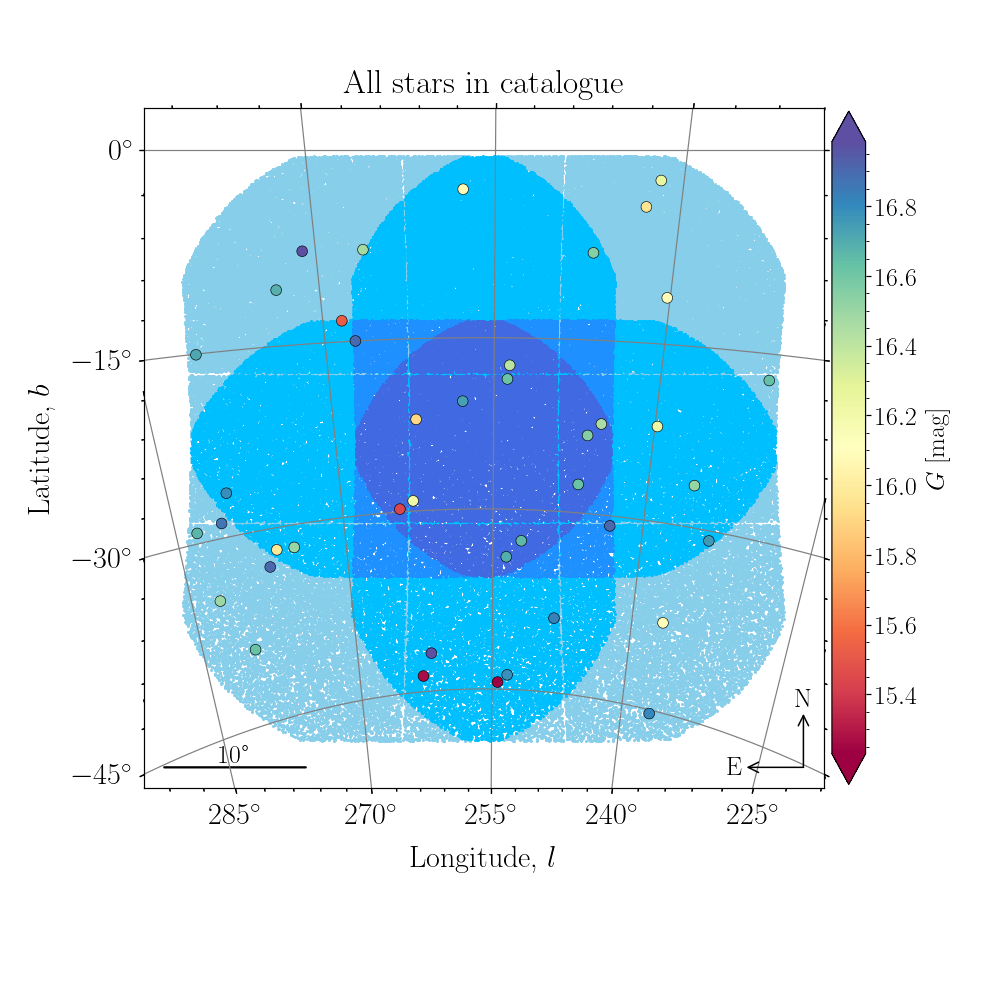

In [5]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=df.Ra, decStars=df.Dec, c=df.Gmag,
    clabel=r'$G$ [mag]', s=200, lw=0.4,
    title='All stars in catalogue', 
    figsize=(9,9),
)
# fig.savefig(fdir / f'aitoff_sample_all.png', bbox_inches='tight', dpi=200)

In [7]:
# Estimates for N-CAM = {6, 12, 18, 24}
# G = 15: Amin = {40, 50, 70, 90}
# G = 16: Amin = {100, 120, 160, 210}
# G = 17: Amin = {600, 800, 1200, 2000}
#


In [50]:
# Rename column in order to match catalogues
dt = df.copy()
dt = dt.rename(columns={'Source':'gaiaDR3', 'Ra':'ra', 'Dec':'dec'})
dt['gaiaDR3'] = [f'Gaia DR3 {i}' for i in dt.gaiaDR3]
dt.head()

,gaiaDR3,ra,dec,Gmag,BPmag,RPmag,BP-RP,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,rmag,imag,zmag,_RA.icrs,_DE.icrs,Unnamed: 27,Unnamed: 28,Unnamed: 29,Separation,type
0,Gaia DR3 4870090943381248128,64.878162,-35.346489,16.8039,16.8402,16.7791,0.0611,NaN,NaN,NaN,...,NaN,NaN,NaN,64.878393,-35.346311,NaN,NaN,NaN,1.549042e-08,DAV
1,Gaia DR3 4811871287295222016,73.501550,-43.379587,16.8211,16.8428,16.8349,0.0079,NaN,NaN,NaN,...,NaN,NaN,NaN,73.499376,-43.379930,NaN,NaN,NaN,3.295129e-09,DAV
2,Gaia DR3 4873109308958466432,73.524457,-34.418209,16.1328,16.1362,16.1778,-0.0416,NaN,NaN,NaN,...,NaN,NaN,NaN,73.524475,-34.418253,NaN,NaN,NaN,2.012231e-08,DAV
3,Gaia DR3 4654695103690489856,73.965790,-70.928558,16.4933,16.5546,16.4263,0.1283,NaN,NaN,NaN,...,NaN,NaN,NaN,73.963867,-70.928280,NaN,NaN,NaN,1.016414e-08,DAV
4,Gaia DR3 2905372374461903488,81.329208,-30.338298,16.7579,16.7600,16.7899,-0.0299,NaN,NaN,NaN,...,NaN,NaN,NaN,81.329018,-30.338368,NaN,NaN,NaN,6.405766e-09,DAV


In [9]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_wd_targets.ftr')

In [10]:
# Load PIC LOSP2 catalogue
dc = pd.read_feather(hdir / 'PlatoGO_PIC210_LOPS2.ftr')
dc.head()

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag
0,3110756000112,Gaia DR3 5212190448627272832,95.193683,-77.886883,15.213778,14.926610,15.235669,14.596222
1,3110756000113,Gaia DR3 5212190616130246656,95.141286,-77.886858,18.240141,17.982211,18.237360,17.696458
2,3110755000134,Gaia DR3 5212191960455806208,94.689049,-77.885060,18.910688,18.488089,19.384377,17.854926
3,3110757000131,Gaia DR3 5212236623819501824,95.869891,-77.885061,17.671410,17.447247,17.651479,17.208032
4,3110757000132,Gaia DR3 5212236417661073152,95.765300,-77.884838,18.137350,17.830000,18.183424,17.466040


In [11]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, dc, column='gaiaDR3')
dc.to_feather(idir / f'starcat_wd_contaminants.ftr')

100%|██████████████████████████████████████████████████| 42/42 [00:08<00:00,  4.87it/s]                                                                              


In [12]:
# Create an parameterisation file
N = dt.shape[0]
from platosim.slurm import getParamFile
getParamFile(range(1,N+1), range(1,5), range(1,2), range(1,2), ofile=idir / 'cluster.data');

In [13]:
# Run simulation for only 1 exposure across all cameras
from platosim.hpc import HPC
hpc = HPC(wdir, cpus=6)
hpc.run(script='platonium', param_file='cluster.data', odir=sdir, kwargs='--nexp 1 -w -v 0')

100%|██████████████████████████████████████████████████| 168/168 [02:10<00:00,  1.29it/s]                                                                            


In [14]:
# Fetch extra parameters from simulation tables
ncon = np.zeros(N) 
SPR = np.zeros(N)
NSR = np.zeros(N)
for i in range(1, N+1):
    star = f'{i}'.zfill(9)
    lcs = LightCurve(sdir/star, mode='multi')
    # Create table with simulation statistics
    if lcs.files() is not None:
        dt_sims = lcs.stat_sim_table(ofile=sdir/f'table_{star}.ftr', clean=False, verbose=False)
        ncon[i-1] = dt_sims.ncon.iloc[0]
        SPR[i-1]  = dt_sims.SPR.mean()
        NSR[i-1]  = dt_sims.NSR.mean()
    else:
        ncon[i-1] = None
        SPR[i-1]  = None
        NSR[i-1]  = None

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_wd_pulsators/sims/000000027


In [51]:
# Columns from simulations
dt0 = dt.copy()
dt0['ncon'] = ncon
dt0['SPR']  = SPR
dt0['NSR']  = NSR
dt0

,gaiaDR3,ra,dec,Gmag,BPmag,RPmag,BP-RP,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,_RA.icrs,_DE.icrs,Unnamed: 27,Unnamed: 28,Unnamed: 29,Separation,type,ncon,SPR,NSR
0,Gaia DR3 4870090943381248128,64.878162,-35.346489,16.8039,16.8402,16.7791,0.0611,NaN,NaN,NaN,...,64.878393,-35.346311,NaN,NaN,NaN,1.549042e-08,DAV,1.0,2.715121e-07,0.223375
1,Gaia DR3 4811871287295222016,73.501550,-43.379587,16.8211,16.8428,16.8349,0.0079,NaN,NaN,NaN,...,73.499376,-43.379930,NaN,NaN,NaN,3.295129e-09,DAV,1.0,2.041725e-06,0.208445
2,Gaia DR3 4873109308958466432,73.524457,-34.418209,16.1328,16.1362,16.1778,-0.0416,NaN,NaN,NaN,...,73.524475,-34.418253,NaN,NaN,NaN,2.012231e-08,DAV,3.0,7.984876e-04,0.116737
3,Gaia DR3 4654695103690489856,73.965790,-70.928558,16.4933,16.5546,16.4263,0.1283,NaN,NaN,NaN,...,73.963867,-70.928280,NaN,NaN,NaN,1.016414e-08,DAV,14.0,1.797016e-01,0.197165
4,Gaia DR3 2905372374461903488,81.329208,-30.338298,16.7579,16.7600,16.7899,-0.0299,NaN,NaN,NaN,...,81.329018,-30.338368,NaN,NaN,NaN,6.405766e-09,DAV,3.0,1.583145e-01,0.223943
5,Gaia DR3 4658691072554066560,81.452805,-67.270378,16.9068,16.9763,16.8370,0.1393,NaN,NaN,NaN,...,81.453154,-67.269885,NaN,NaN,NaN,9.361261e-09,DAV,20.0,2.861701e-02,0.308839
6,Gaia DR3 4799224635833122304,82.752793,-45.966442,16.6616,16.7033,16.6113,0.0920,NaN,NaN,NaN,...,82.752052,-45.966984,NaN,NaN,NaN,1.323831e-08,DAV,1.0,6.665421e-06,0.185244
7,Gaia DR3 4659528969150132096,84.916583,-66.698515,15.9819,15.9923,16.0194,-0.0271,NaN,NaN,NaN,...,84.915355,-66.699401,NaN,NaN,NaN,1.407181e-08,DAV,8.0,4.812807e-02,0.132082
8,Gaia DR3 4804209684114310784,88.616773,-40.432083,16.6271,16.6187,16.6807,-0.0620,NaN,NaN,NaN,...,88.616881,-40.431974,NaN,NaN,NaN,1.656566e-08,DAV,1.0,4.460100e-04,0.182473
9,Gaia DR3 5500308124837433984,90.054310,-54.921303,16.2137,16.2403,16.2216,0.0187,NaN,NaN,NaN,...,90.054439,-54.921121,NaN,NaN,NaN,1.671072e-08,DAV,1.0,2.469583e-05,0.123812


<IPython.core.display.Javascript object>


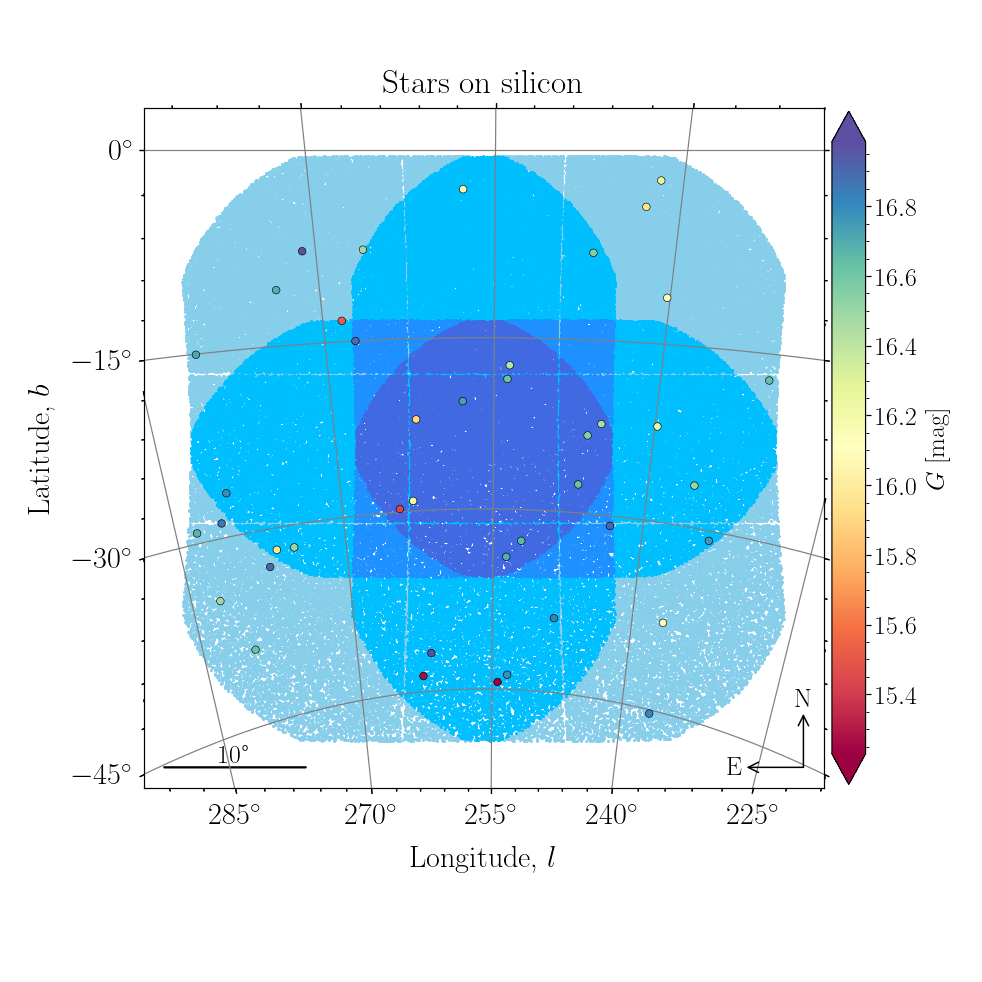

In [16]:
# Inspect the star not detected on silicon
dx = dt0.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Gmag,
    clabel=r'$G$ [mag]', s=100, lw=0.4,
    title='Stars on silicon', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_on_silicon.png', bbox_inches='tight', dpi=200)

In [17]:
# Inspect stars not detected by PlatoSIm
dt1 = dt0[dt0.SPR.isna()]
dt1

,gaiaDR3,ra,dec,Gmag,BPmag,RPmag,BP-RP,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,zmag,_RA.icrs,_DE.icrs,Unnamed: 27,Unnamed: 28,Unnamed: 29,Separation,ncon,SPR,NSR
26,Gaia DR3 5278615205944625664,92.787971,-70.65557,16.8651,16.7431,17.0798,-0.3367,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<IPython.core.display.Javascript object>


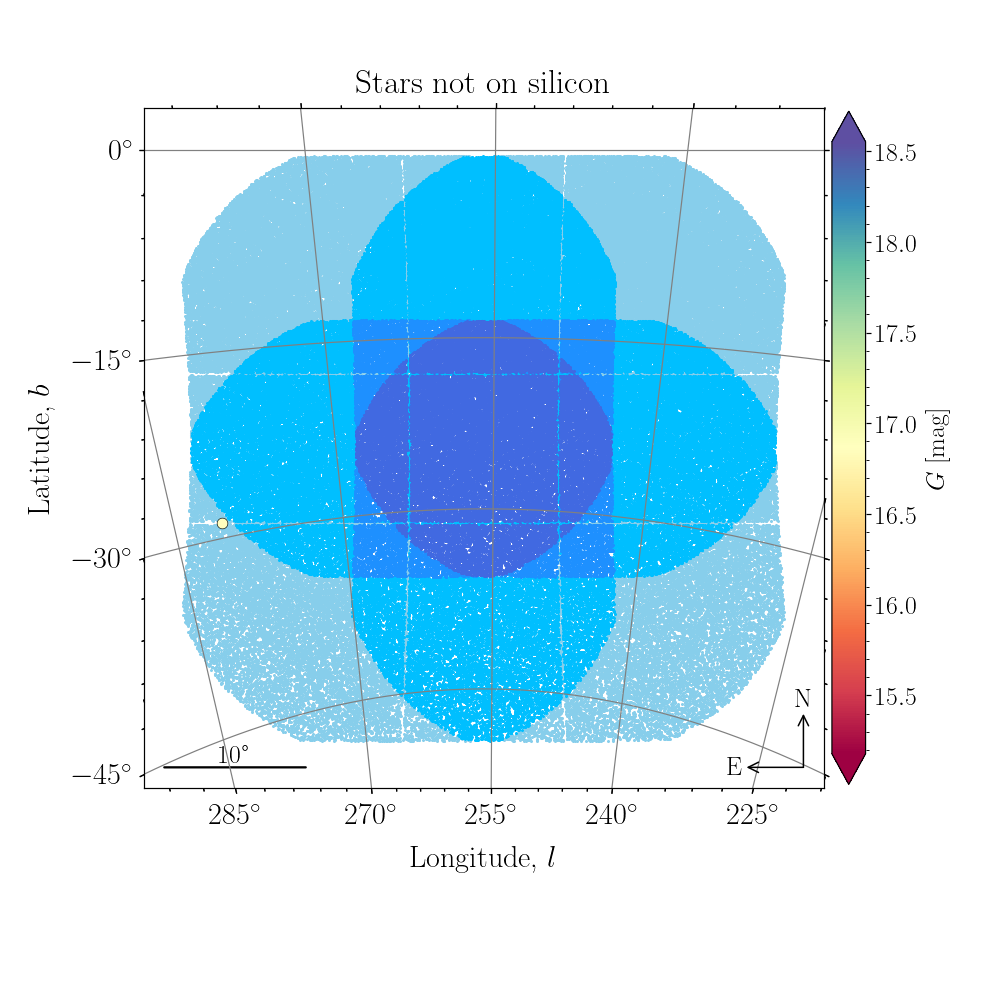

In [20]:
# Inspect the star not detected on silicon
dx = dt1.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Gmag,
    clabel=r'$G$ [mag]', s=200, lw=0.4,
    title='Stars not on silicon', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_not_on_silicon.png', bbox_inches='tight', dpi=200)

In [34]:
dt0[dt0.SPR > 0.1]

,gaiaDR3,ra,dec,Gmag,BPmag,RPmag,BP-RP,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,zmag,_RA.icrs,_DE.icrs,Unnamed: 27,Unnamed: 28,Unnamed: 29,Separation,ncon,SPR,NSR
3,Gaia DR3 4654695103690489856,73.965790,-70.928558,16.4933,16.5546,16.4263,0.1283,NaN,NaN,NaN,...,NaN,73.963867,-70.928280,NaN,NaN,NaN,1.016414e-08,14.0,0.179702,0.197165
4,Gaia DR3 2905372374461903488,81.329208,-30.338298,16.7579,16.7600,16.7899,-0.0299,NaN,NaN,NaN,...,NaN,81.329018,-30.338368,NaN,NaN,NaN,6.405766e-09,3.0,0.158314,0.223943
14,Gaia DR3 5315128548292806656,128.194004,-57.690182,16.6886,16.7036,16.7192,-0.0156,NaN,NaN,NaN,...,NaN,128.194086,-57.690415,NaN,NaN,NaN,1.051233e-08,10.0,0.111641,0.238306


<IPython.core.display.Javascript object>


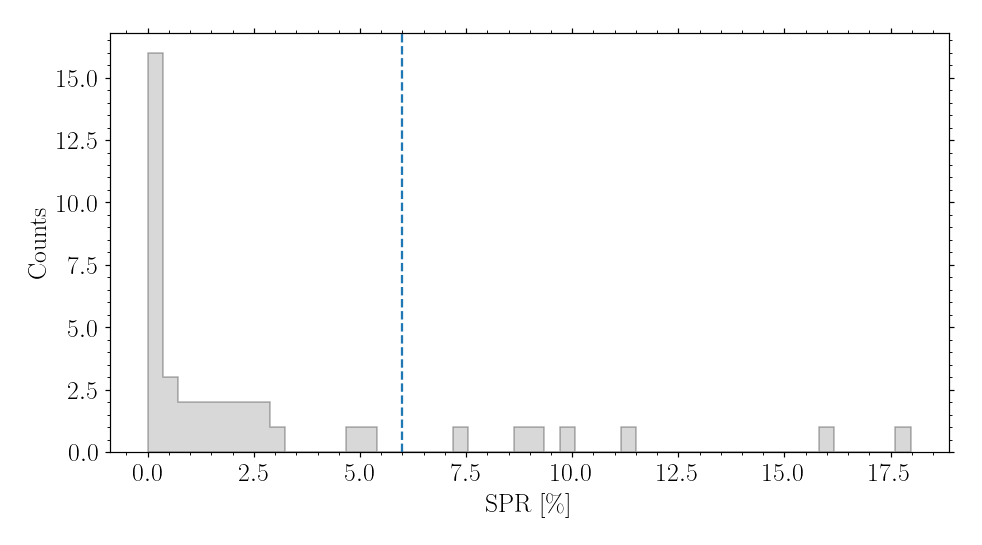

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(9,5))
ax.hist(dt0.SPR * 100, bins=50, histtype='stepfilled', color='gray', ec='k', lw=1, alpha=0.3, label='All')
ax.set_xlabel('SPR [\%]')
ax.set_ylabel('Counts')
ax.axvline(6, ls='--')
plt.tight_layout();
# Save figure
fig.savefig(fdir / f'sample_hist_SPR.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


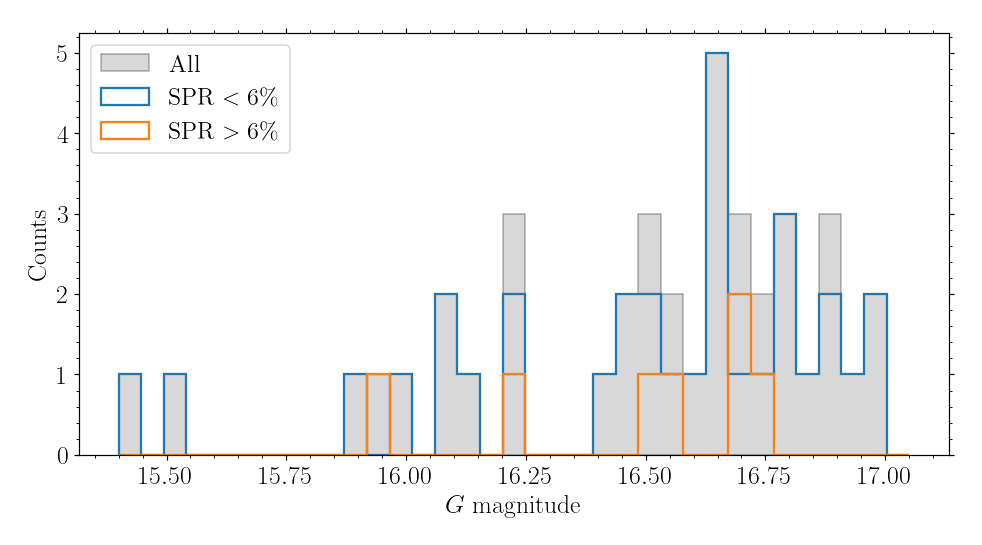

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(9,5))
xmin, xmax = 15.4, 17.05
N = 35
ax.hist(dt0.Gmag, bins=N, range=(xmin, xmax), histtype='stepfilled', color='gray', ec='k', lw=1, alpha=0.3, label='All')
ax.hist(dt0[dt0.SPR < 0.06].Gmag, bins=N, range=(xmin, xmax), histtype='step', lw=1.5, label=r'SPR $< 6\%$')
ax.hist(dt0[dt0.SPR > 0.06].Gmag, bins=N, range=(xmin, xmax), histtype='step', lw=1.5, label=r'SPR $> 6\%$')
# Settings
ax.set_xlabel('$G$ magnitude')
ax.set_ylabel('Counts')
ax.legend(loc='upper left', fontsize=16)
plt.tight_layout();
# Save figure
fig.savefig(fdir / f'sample_hist_Gmag.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


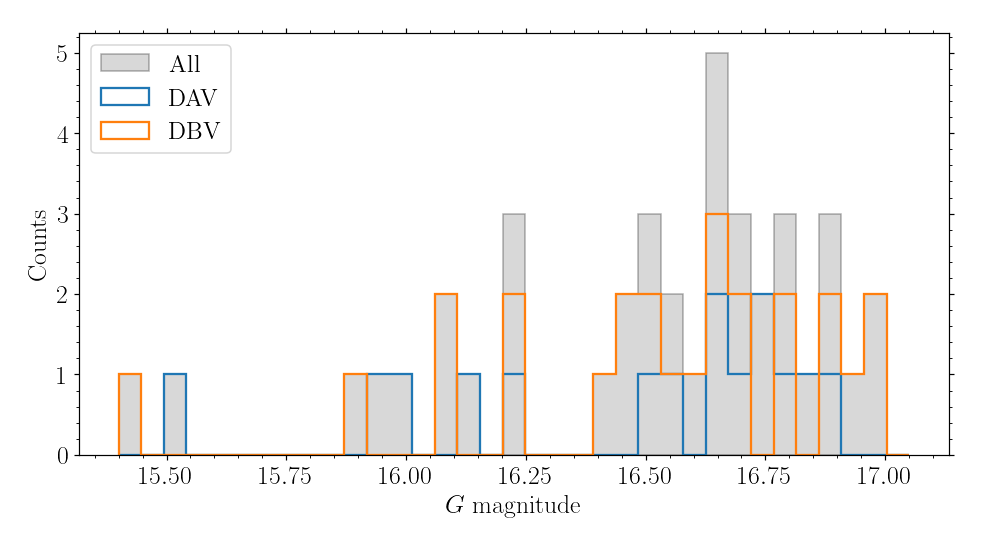

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(9,5))
xmin, xmax = 15.4, 17.05
N = 35
ax.hist(dt0.Gmag, bins=N, range=(xmin, xmax), histtype='stepfilled', color='gray', ec='k', lw=1, alpha=0.3, label='All')
ax.hist(dt0[dt0.type == 'DAV'].Gmag, bins=N, range=(xmin, xmax), histtype='step', lw=1.5, label='DAV')
ax.hist(dt0[dt0.type == 'DBV'].Gmag, bins=N, range=(xmin, xmax), histtype='step', lw=1.5, label='DBV')
# Settings
ax.set_xlabel('$G$ magnitude')
ax.set_ylabel('Counts')
ax.legend(loc='upper left', fontsize=16)
plt.tight_layout();
# Save figure
fig.savefig(fdir / f'sample_hist_Gmag_DAVvsDBV.png', bbox_inches='tight', dpi=200)

In [59]:
dt0[(dt0.type == 'DAV') & (dt0.Gmag > 16.5)]

,gaiaDR3,ra,dec,Gmag,BPmag,RPmag,BP-RP,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,_RA.icrs,_DE.icrs,Unnamed: 27,Unnamed: 28,Unnamed: 29,Separation,type,ncon,SPR,NSR
0,Gaia DR3 4870090943381248128,64.878162,-35.346489,16.8039,16.8402,16.7791,0.0611,NaN,NaN,NaN,...,64.878393,-35.346311,NaN,NaN,NaN,1.549042e-08,DAV,1.0,2.715121e-07,0.223375
1,Gaia DR3 4811871287295222016,73.501550,-43.379587,16.8211,16.8428,16.8349,0.0079,NaN,NaN,NaN,...,73.499376,-43.379930,NaN,NaN,NaN,3.295129e-09,DAV,1.0,2.041725e-06,0.208445
4,Gaia DR3 2905372374461903488,81.329208,-30.338298,16.7579,16.7600,16.7899,-0.0299,NaN,NaN,NaN,...,81.329018,-30.338368,NaN,NaN,NaN,6.405766e-09,DAV,3.0,1.583145e-01,0.223943
5,Gaia DR3 4658691072554066560,81.452805,-67.270378,16.9068,16.9763,16.8370,0.1393,NaN,NaN,NaN,...,81.453154,-67.269885,NaN,NaN,NaN,9.361261e-09,DAV,20.0,2.861701e-02,0.308839
6,Gaia DR3 4799224635833122304,82.752793,-45.966442,16.6616,16.7033,16.6113,0.0920,NaN,NaN,NaN,...,82.752052,-45.966984,NaN,NaN,NaN,1.323831e-08,DAV,1.0,6.665421e-06,0.185244
8,Gaia DR3 4804209684114310784,88.616773,-40.432083,16.6271,16.6187,16.6807,-0.0620,NaN,NaN,NaN,...,88.616881,-40.431974,NaN,NaN,NaN,1.656566e-08,DAV,1.0,4.460100e-04,0.182473
10,Gaia DR3 5551402808137892864,102.010251,-48.511114,16.7348,16.7516,16.7573,-0.0057,NaN,NaN,NaN,...,102.010241,-48.510878,NaN,NaN,NaN,1.385985e-08,DAV,5.0,2.805528e-02,0.201509
11,Gaia DR3 5592485716514387584,111.822981,-33.477565,16.5501,16.5254,16.5165,0.0089,NaN,NaN,NaN,...,111.822836,-33.477268,NaN,NaN,NaN,1.137311e-08,DAV,21.0,7.414819e-02,0.226360
14,Gaia DR3 5315128548292806656,128.194004,-57.690182,16.6886,16.7036,16.7192,-0.0156,NaN,NaN,NaN,...,128.194086,-57.690415,NaN,NaN,NaN,1.051233e-08,DAV,10.0,1.116412e-01,0.238306


<IPython.core.display.Javascript object>


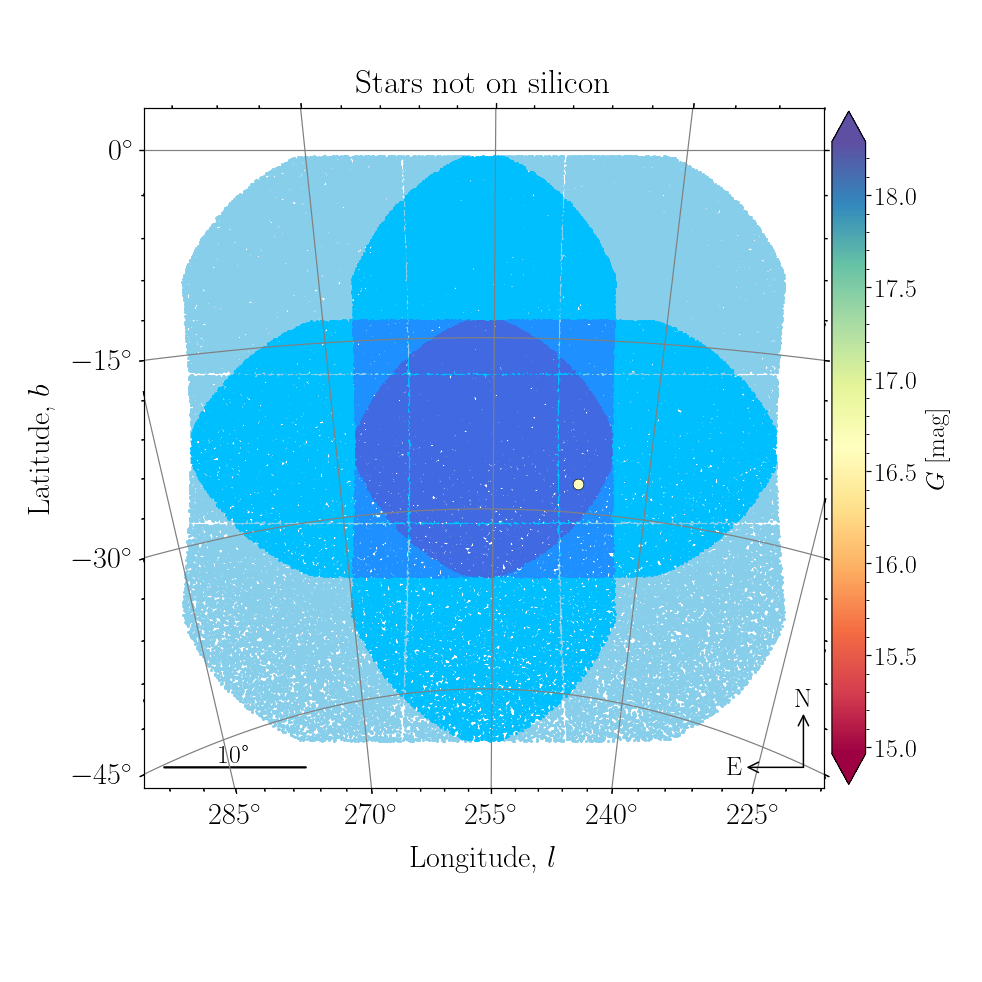

In [69]:
# Inspect the star not detected on silicon
dx = dt0.iloc[8]
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Gmag,
    clabel=r'$G$ [mag]', s=200, lw=0.4,
    title='Stars not on silicon', figsize=(9,9),
)

In [33]:
# Save catalogue
dt0.to_csv(ddir / 'LOPS2_WD_on_silicon.csv', index=False)